1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


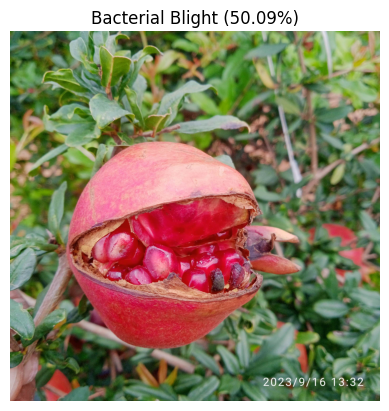

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step


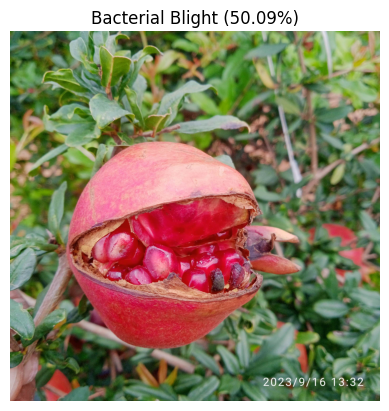

In [2]:
import numpy as np
import tensorflow as tf
import cv2

# ==============================
# 1. LOAD MODEL
# ==============================


model = tf.keras.models.load_model("mobilenet_pomegranate_model.keras")

# ==============================
# 2. CLASS NAMES (IMPORTANT)
# ==============================

class_names = [
    "Alternaria",
    "Anthracnose",
    "Bacterial Blight",
    "Cercospora",
    "Healthy"
]

# ==============================
# 4. PREDICTION FUNCTION
# ==============================

import matplotlib.pyplot as plt

def predict_and_show(img_path):

    img = cv2.imread(img_path)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    img_processed = preprocess_image(img_path)

    preds = model.predict(img_processed)

    class_index = np.argmax(preds[0])
    confidence = np.max(preds[0])

    label = f"{class_names[class_index]} ({confidence*100:.2f}%)"

    plt.imshow(img_rgb)
    plt.title(label)
    plt.axis("off")
    plt.show()

predict_and_show(img_path)

# ==============================
# 5. TEST IMAGE
# ==============================

img_path = "/home/ravjot/datasets/Pomegranate Diseases Dataset/Bacterial_Blight/IMG_20230916_133222_1.jpg"

predict_and_show(img_path)